## Data Wrangling

Recall our data wrangling process.  

1. Discovering
2. Structuring
3. Cleaning 
4. Enriching
5. Validating
6. Publishing

We explored this a bit with Part 1. Let's do a bit more today with Part 2 so we can look at a few more techniques. Mainly we'll look at:
* categories and groupby for discovering
* feature scaling and extraction for structuring
* dirty data and outliers for cleaning

This will be followed by our next lab. 

### 1. Discovering

We are going to continue using the data concerning college student food preferences. This data is the result of a student survey at Mercyhurst University. The file is: food_coded.csv

Data is from https://www.kaggle.com/datasets/borapajo/food-choices/data. About the data: "This dataset includes information on food choices, nutrition, preferences, childhood favorites, and other information from college students. There are 126 responses from students. Data is raw and uncleaned."

Let's do our import and load this data.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# needed for structuring step - scaling
from sklearn.preprocessing import MinMaxScaler

In [10]:
# Load the dataset
df = pd.read_csv("food_coded.csv")

In [12]:
# Do our typical review of the data to get started
# see first five and last five observations

# Note that this does not show us all columns
pd.pandas.set_option('display.max_columns', None)

df

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,cook,comfort_food_reasons_coded.1,cuisine,diet_current,diet_current_coded,drink,eating_changes,eating_changes_coded,eating_changes_coded1,eating_out,employment,ethnic_food,exercise,father_education,father_profession,fav_cuisine,fav_cuisine_coded,fav_food,food_childhood,fries,fruit_day,grade_level,greek_food,healthy_feeling,healthy_meal,ideal_diet,ideal_diet_coded,income,indian_food,italian_food,life_rewarding,marital_status,meals_dinner_friend,mother_education,mother_profession,nutritional_check,on_off_campus,parents_cook,pay_meal_out,persian_food,self_perception_weight,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,2.0,9,NaN,eat good and exercise,1,1.0,eat faster,1,1,3,3.0,1,1.0,5.0,profesor,Arabic cuisine,3,1.0,rice and chicken,2,5,2,5,2,looks not oily,being healthy,8,5.0,5,5,1.0,1.0,"rice, chicken, soup",1.0,unemployed,5,1.0,1,2,5.0,3.0,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,3.0,1,1.0,I eat about three times a day with some snacks...,2,2.0,I eat out more than usual.,1,2,2,2.0,4,1.0,2.0,Self employed,Italian,1,1.0,"chicken and biscuits, beef soup, baked beans",1,4,4,4,5,"Grains, Veggies, (more of grains and veggies),...",Try to eat 5-6 small meals a day. While trying...,3,4.0,4,4,1.0,2.0,"Pasta, steak, chicken",4.0,Nurse RN,4,1.0,1,4,4.0,3.0,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,1.0,1,3.0,"toast and fruit for breakfast, salad for lunch...",3,1.0,sometimes choosing to eat fast food instead of...,1,3,2,3.0,5,2.0,2.0,owns business,italian,1,3.0,"mac and cheese, pizza, tacos",1,5,3,5,6,usually includes natural ingredients; nonproce...,i would say my ideal diet is my current diet,6,6.0,5,5,7.0,2.0,"chicken and rice with veggies, pasta, some kin...",2.0,owns business,4,2.0,1,3,5.0,6.0,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,2.0,2,2.0,"College diet, cheap and easy foods most nights...",2,2.0,Accepting cheap and premade/store bought foods,1,3,2,3.0,5,3.0,2.0,Mechanic,Turkish,3,1.0,"Beef stroganoff, tacos, pizza",2,4,4,5,7,"Fresh fruits& vegetables, organic meats","Healthy, fresh veggies/fruits & organic foods",2,6.0,5,5,2.0,2.0,Grilled chicken \rStuffed Shells\rHomemade Chili,4.0,Special Education Teacher,2,1.0,1,2,5.0,5.0,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,1.0,1,2.0,I try to eat healthy but often struggle becaus...,2,2.0,I have eaten generally the same foods but I do...,3,4,2,2.0,4,1.0,4.0,IT,Italian,1,3.0,"Pasta, chicken tender, pizza",1,4,4,4,6,"A lean protein such as grilled chicken, green ...",Ideally I would like to be able to eat healthi...,2,6.0,2,5,1.0,1.0,"Chicken Parmesan, Pulled Pork, Spaghetti and m...",5.0,Substance Abuse Conselor,3,1.0,1,4,2.0,4.0,1.0,1.0,4,940.0,500,Softball,4,2,760,190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,3,1,1,265,2.0,315.0,2,Pizza / Wings / Cheesecake,Loneliness / Homesick / Sadness,NaN,3.0,3,NaN,A college student with an imbalanced diet tryi...,2,1.0,Eating Pizza as an excuse when there is nothin...,1,3,4,3.0,3,2.0,5.0,Doctor,Mexican Food,2,1.0,"Isombe , Plantains and Ugali",1,4,4,1,5,"A healthy meal is a variety of food , organic ...",Eating home cooked meals everyday and being ab...,5,2.0,5,5,7.0,1.0,Fried Rice \rBaked potatoes \rCurry Chicken,2.0,Public Health Advisor

In [14]:
df.describe()

,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food_reasons_coded,cook,comfort_food_reasons_coded.1,cuisine,diet_current_coded,drink,eating_changes_coded,eating_changes_coded1,eating_out,employment,ethnic_food,exercise,father_education,fav_cuisine_coded,fav_food,fries,fruit_day,grade_level,greek_food,healthy_feeling,ideal_diet_coded,income,indian_food,italian_food,life_rewarding,marital_status,mother_education,nutritional_check,on_off_campus,parents_cook,pay_meal_out,persian_food,self_perception_weight,soup,sports,thai_food,tortilla_calories,turkey_calories,veggies_day,vitamins,waffle_calories
count,126.000000,126.000000,126.000000,106.000000,125.000000,126.000000,106.000000,122.000000,126.000000,109.000000,126.000000,124.000000,126.000000,126.000000,126.000000,117.000000,126.000000,113.000000,125.000000,126.000000,124.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,125.000000,126.000000,126.000000,125.000000,125.000000,123.000000,126.000000,125.000000,126.000000,126.000000,125.000000,125.000000,125.00000,124.000000,126.000000,125.000000,126.000000,126.000000,126.000000,126.000000
mean,1.388889,1.111111,576.150794,3.028302,503.720000,1.753968,2.698113,2.786885,2.706349,1.403670,1.753968,1.556452,1.539683,4.555556,2.547619,2.444444,3.738095,1.592920,3.488000,2.420635,1.709677,1.087302,4.214286,2.380952,3.476190,5.436508,3.698413,4.536000,3.142857,4.714286,5.104000,1.504000,3.422764,3.166667,1.320000,1.539683,3.404762,2.800000,3.120000,1.21600,1.395161,3.325397,945.800000,553.373016,4.007937,1.515873,1069.444444
std,0.489444,0.315524,131.345594,0.639308,230.536632,0.432417,1.972042,1.038351,1.914440,0.982431,0.766149,0.498818,0.755257,2.537891,1.142679,0.532471,1.174247,0.663287,1.202256,1.940528,0.908623,0.283403,0.926129,1.130360,1.366539,2.584557,2.079499,1.451051,1.484395,0.604743,3.107805,0.548076,1.166529,1.211610,0.679184,0.755257,1.036753,1.419905,1.111523,0.41317,0.490869,1.435712,202.255827,152.908900,1.077003,0.501743,251.618936
min,1.000000,1.000000,265.000000,2.000000,315.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.00000,1.000000,1.000000,580.000000,345.000000,1.000000,1.000000,575.000000
25%,1.000000,1.000000,430.000000,3.000000,420.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000,1.000000,1.000000,4.000000,1.000000,3.000000,3.000000,2.000000,4.000000,2.000000,5.000000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,3.000000,2.000000,2.000000,1.00000,1.000000,2.000000,725.000000,500.000000,3.000000,1.000000,900.000000
50%,1.000000,1.000000,610.000000,3.000000,420.000000,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,1.000000,4.000000,2.000000,2.000000,4.000000,1.000000,4.000000,1.000000,1.000000,1.000000,4.500000,2.000000,4.000000,5.000000,3.000000,5.000000,3.000000,5.000000,5.000000,1.000000,4.000000,3.000000,1.000000,1.000000,3.000000,3.000000,3.000000,1.00000,1.000000,3.000000,940.000000,500.000000,4.000000,2.000000,900.000000
75%,2.000000,1.000000,692.500000,3.000000,420.000000,2.000000,3.000000,3.000000,3.000000,1.000000,2.000000,2.000000,2.000000,5.000000,3.000000,3.000000,5.000000,2.000000,4.000000,4.000000,3.000000,1.000000,5.000000,3.000000,5.000000,8.000000,5.750000,6.000000,5.000000,5.000000,8.000000,2.000000,4.000000,4.000000,1.000000,2.000000,4.000000,4.000000,4.000000,1.00000,2.000000,5.000000,1165.000000,690.000000,5.000000,2.000000,1315.000000
max,2.000000,2.000000,720.000000,4.000000,980.000000,2.000000,9.000000,5.000000,9.000000,6.000000,4.000000,2.000000,4.000000,13.000000,5.000000,3.000000,5.000000,3.000000,5.000000,8.000000,3.000000,2.000000,5.000000,4.000000,5

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           124 non-null    object 
 1   Gender                        126 non-null    int64  
 2   breakfast                     126 non-null    int64  
 3   calories_chicken              126 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                125 non-null    float64
 6   coffee                        126 non-null    int64  
 7   comfort_food                  125 non-null    object 
 8   comfort_food_reasons          124 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  126 non-null    int64  
 12  cuisine                       109 non-null    float64
 13  diet_

Let's use a bit of grouping to learn about the data. However, we have quite a few fields that should be categories (factors) instead of numbers or objects.

Let's consider the features: gender, coffee, and cuisine.

In [ ]:
# convert to factors/categories
df["Gender"] = df["Gender"].astype("category")
df["coffee"] = df["coffee"].astype("category")
df["cuisine"] = df["cuisine"].astype("category")

In [19]:
# explore what we have with groupby
# common aggregation functions are sum, mean, size, count, min, max, std, var, first, and last
# recall that as_index=False gets us a dataframe as the result
gender_group = df.groupby("Gender", as_index=False).size()
gender_group



,Gender,size
0,1,77
1,2,49


In [21]:
# don't forget that we can groupby multiple
gender_group = df.groupby(["Gender", "coffee"], as_index=False).size()
gender_group

,Gender,coffee,size
0,1,1,18
1,1,2,59
2,2,1,13
3,2,2,36


### 2. Structuring

Next we'll structure the data. We want to standardize the format and fix any formatting issues.  Are the units okay? Do we have any date/time issues? Are there case issues? ...

Last time we explored the following functions:
* value_counts() for features that are categorical, we can see the unique categories and their counts
* astype() for converting column to correct data type
* fillna() for replacing NaNs with a number
* string manipulation functions (e.g. replace(), strip(), lower(), ...)
* and more

Let's also look at feature scaling which may be necessary. Again, the choice of whether or not to scale a feature depends on situation.  

And then we'll look at how to extract features from an existing feature.  

Example 1: Let's say we are going to to use k-means clustering to place observations into clusters. K-means requires feature scaling.  So let's use normalization, often called min-max scaling to appropriately convert the feature. This will make the minimum value of the feature 0 and the max value 1, and scale values in-between this range appropriately. While we would need to do this for many of the features, let's for now just do this for calories_scone. Note: we **can** do this for multiple features at the same time. 

Steps are:
1. Create scaler
2. Apply scaler
3. Update/Get DataFrame 

We'll use the MinMaxScaler() function. The default range is between 0 and 1, but we can customize that with the function. This is part of the preprocessing module of the sklearn library. We'll be using this library more in the future. 

Note that your book does this all in one line of code:
<code>normalizedArray = preprocessing.MinMaxScaler().fit_transform(original)</code>


In [24]:
# Let's see what we have first
df["calories_scone"].describe()

count    125.000000
mean     503.720000
std      230.536632
min      315.000000
25%      420.000000
50%      420.000000
75%      420.000000
max      980.000000
Name: calories_scone, dtype: float64

Let's make sure the data is ready for normalization first. Currently the data is a float, so our data type is okay. But we can check for nulls. We can also leave this step for later when we clean if we prefer. Note that the scaler will just ignore missing values, so we don't need to do this. 

In [26]:
# Get observations where value(s) are missing
missing = pd.isnull(df["calories_scone"]) # note isnull vs isna?

# see which observations are missing
df[missing]

# let's just fill it with average
df.calories_scone = df.calories_scone.fillna(df.calories_scone.mean())

In [28]:
# Let's use MinMaxScaler
# This require additional import statement -- added to our import section above
scaler = MinMaxScaler()

df["calories_scone_scaled"] = scaler.fit_transform(df[["calories_scone"]])

# now review the values
df["calories_scone_scaled"].describe()

count    126.000000
mean       0.283789
std        0.345282
min        0.000000
25%        0.157895
50%        0.157895
75%        0.157895
max        1.000000
Name: calories_scone_scaled, dtype: float64

Text(0.5, 0, 'calories')

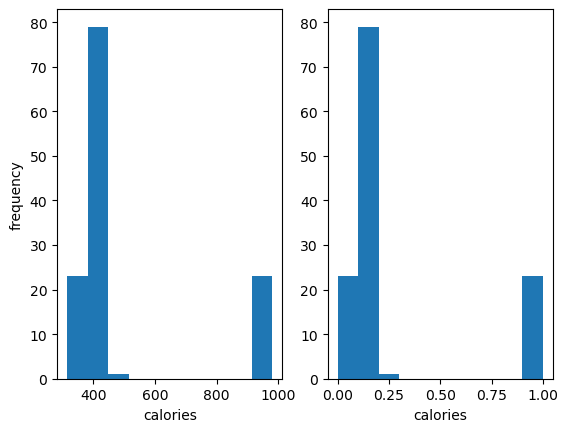

In [30]:
# Let's just see visually what this did
plt.subplot(1, 2, 1)
plt.hist(df["calories_scone"], bins=10)
plt.xlabel("calories")
plt.ylabel("frequency")

plt.subplot(1, 2, 2)
plt.hist(df["calories_scone_scaled"], bins=10)
plt.xlabel("calories")


The above shows us that the distribution of the values has not changed, only the range has changed.

Example 2: We have a feature that is not simple. We need to extract the data and create features. We don't really have a good example of this in our data above, so I've created a short example.

In [32]:
# Our made up data
courses = ["CIT160", "CSC132", "CIT482", "EET145"]
coursesDf = pd.DataFrame(courses, columns=["Course"])
coursesDf

,Course
0,CIT160
1,CSC132
2,CIT482
3,EET145


We want to get the subject and number in different columns. We can use other functions of the string class in Python to access these values.

Functions/functionality such as:
* str[] - this is just standard slicing
* slice()

In [36]:
# create a new column/feature called "Subject" that contains just the subject (first 3 letters)
coursesDf["Subject"] = coursesDf["Course"].str[:3]
# use slightly different approach below for course number (slice())
coursesDf["Number"] = coursesDf["Course"].str.slice(3)
coursesDf

,Course,Subject,Number
0,CIT160,CIT,160
1,CSC132,CSC,132
2,CIT482,CIT,482
3,EET145,EET,145


Let's look at some additional cleaning techniques next.

### 3. Data Cleaning

We look for dirty data (e.g. duplicates, missing data, outliers, duplicates). 

In [38]:
# Consider the following dirty list
dirty = {
    'Name': [None, ' ', '        ', ''],
    'Age': [None, np.NaN , np.NaN, np.NaN],
    'Start': [None, pd.NaT, pd.NaT, pd.NaT],
}
dirtyDf = pd.DataFrame(dirty)
dirtyDf

,Name,Age,Start
0,None,NaN,NaT
1,,NaN,NaT
2,,NaN,NaT
3,,NaN,NaT


As we saw last time, there are many functions what will help use here:
* duplicated() to determine which records/observations/instances are duplicates
* drop_duplicates() to drop duplicate records
* isnull() to detect missing values - returns boolean values
* isna() to detect missing values - returns boolean values (alias of above)
* dropna() to drop rows with missing values
* drop() to drop a feature/column

Will they pick up on everything "dirty" in our dirty DataFrame above?

In [40]:
# check for missing data
dirtyDf.isna()

,Name,Age,Start
0,True,True,True
1,False,True,True
2,False,True,True
3,False,True,True


In [ ]:
# We can replace empty strings with a regex
dirtyDf.replace(r"^\s*$", np.nan, inplace=True, regex=True)
dirtyDf

Next we'll consider if data has outliers. There are several techniques we can use here. We can look at percentiles and remove anything outside of the 5% to 95% range.  We can use z-scores and remove anything above 3 or below -3. Standardized scores (z-scores) describe how many standard deviations—and in which direction—a value lies from the distribution's mean. 

Like addressing missing values, you should consider if these outliers are random or not, and also how they should be treated (e.g. dropped, replaced with mean/median).

In [42]:
# Need to clean up first
# remove anything not a digit or a period - data type is wrong so there is text garbage
df["GPA"] = df["GPA"].str.replace('[^0-9\\.]', "", regex=True) # remove garbage

In [44]:
# how many are missing
df["GPA"].isna().sum() 

2

In [46]:
# convert feature to correct type and fill missing values
df["GPA"] = pd.to_numeric(df["GPA"], errors="coerce") # convert failures to NaN
df["GPA"] = df["GPA"].astype(float) #errors
df["GPA"] = df["GPA"].fillna(df["GPA"].mean())

In [48]:
df["GPA"].isna().sum() 

0

In [50]:
# find z-scores
# get mean of GPA
mean = df["GPA"].mean()
# get std of GPA
std = df["GPA"].std()
# We can add this as a new feature and then filter by it to drop rows
# zscore = (current GPA - mean)/std
df["zscore_GPA"] = (df["GPA"] - mean)/std
df["zscore_GPA"]

0     -2.659438
1      0.601799
2     -0.318838
3     -0.578904
4      0.201296
         ...   
121   -1.099038
122    1.194751
123   -1.099038
124    1.241563
125    1.241563
Name: zscore_GPA, Length: 126, dtype: float64

In [52]:
# filter to see just outliers
# remember parens below are needed for logical &
df[(df["zscore_GPA"] > 3) | (df["zscore_GPA"] < -3)]

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,cook,comfort_food_reasons_coded.1,cuisine,diet_current,diet_current_coded,drink,eating_changes,eating_changes_coded,eating_changes_coded1,eating_out,employment,ethnic_food,exercise,father_education,father_profession,fav_cuisine,fav_cuisine_coded,fav_food,food_childhood,fries,fruit_day,grade_level,greek_food,healthy_feeling,healthy_meal,ideal_diet,ideal_diet_coded,income,indian_food,italian_food,life_rewarding,marital_status,meals_dinner_friend,mother_education,mother_profession,nutritional_check,on_off_campus,parents_cook,pay_meal_out,persian_food,self_perception_weight,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight,calories_scone_scaled,zscore_GPA
5,2.25,1,1,610,3.0,980.0,2,"Candy, brownies and soda.","None, i don't eat comfort food. I just eat whe...",4.0,3.0,4,NaN,My current diet is terrible. I barely have tim...,2,2.0,Eating rice everyday. Eating less homemade food.,1,3,1,3.0,4,2.0,1.0,Taxi Driver,African,6,3.0,"Fries, plaintain & fried fish",1,2,2,2,4,"Requires veggies, fruits and a cooked meal.",My ideal diet is to eat 3 times a day includin...,2,1.0,5,5,4.0,2.0,Anything they'd want. I'd ask them before hand...,1.0,Hair Braider,1,1.0,2,5,5.0,5.0,1.0,2.0,4,940.0,345,None.,1,2,1315,190,1.000000,-3.049538
19,2.20,2,1,430,2.0,420.0,2,"pizza, wings, Chinese","boredom, sadness, hungry",2.0,4.0,2,1.0,Current diet right now isn't very good. I eat ...,2,2.0,None really,3,4,2,3.0,3,2.0,5.0,architect,Italian,1,1.0,manacotti,1,2,1,3,4,"lots of fruits and vegitibles, not any fried f...",Something that tastes good and also is good fo...,3,5.0,2,5,7.0,1.0,"chicken, manicotti, rice",4.0,physical therapist,1,1.0,1,3,3.0,4.0,1.0,NaN,3,940.0,345,basketball,2,2,900,165,0.157895,-3.179571


Note: Lab Exercise assigned